# HW 13 - Introduction to SciPy
ULAB - Physics and Astronomy Division
Due **Sunday, February 16th, 2025 at 11:59 PM** on Gradescope.

------

## 0 Academic Integrity

Please type the following message in the cell below as a comment. Sign with your name.

------

**I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.**

------


In [162]:
# Your comment here
'''
I certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.
Manank Doshi
'''

'\nI certify that I did not use AI tools, such as ChatGPT, to generate or write code for this assignment. All work submitted is my own and reflects my understanding of the material.\nManank Doshi\n'

## 1 Simulate a Pendulum
A simple pendulum follows the equation:

$$
\frac{\text{d}^2\theta}{\text{d}t^2} + \frac{g}{L}\sin(\theta) = 0
$$

The goal is to **numerically solve the equation** and compare it to the small-angle approximation.

***Small-Angle Approximation:** a mathematical simplification used in physics when dealing with osciallatory motion, particularly for pendulums and trigonometric funcitons in general.*

Import `numpy`, `matplotlib` and `solve_ivp` in the cell below.

In [163]:
# Your code here 
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

Define the acceleration of gravity $g$ (two significant digits is fine) and the length of the pendulum $l$ in the cell below to **1 meter**.

In [164]:
# Your code here
g = 9.81 # meters/s^2
L = 1.0 # meters

Write a **function** called `pendulum` that contain the arguments `t` and `y`. Write out the differential equation. Follow the structure Brianna gave in lecture, it's very similar.

*Hint: The variable domega/dt should be equal to -(g / L) * np.sin(theta)*. I'll let you take care of the rest. 

In [165]:
# Your code here
def pendulum(t,y):
    theta, omega = y # y[0] = theta, y[1] omega
    dtheta_dt = omega
    domega_dt = -(g/L) * np.sin(theta)
    return [dtheta_dt, domega_dt]

Give you equation some initial conditions. Run the cell below.

In [166]:
theta_0 = np.radians(10) # Convert 10 degrees to radians
omega_0 = 0.0 # Initial angular velocity

Solve the differential equation using `solve_ivp`. Set the simulation time to **10 seconds** and the time for evaluation to **10 steps**.

In [167]:
# Your code here
t_span = (0,10)
t_eval = np.linspace(0,10,500)
sol = solve_ivp(pendulum, t_span, [theta_0, omega_0], t_eval=t_eval)

Extrac the **theta** values (`sol.y`) and the **time** values (`sol.t`).

In [168]:
# Your code here
theta_values = sol.y[0]
time_values = sol.t

Calculate the theoretical period (aka small-angle approximation).

*Hint: Use `2 * np.pi * np.sqrt(L / g)`.*

In [169]:
# Your code here
period = 2 * np.pi * np.sqrt(L/g)

Print out the theoretical period (small-angle approximation) to **two** significant digits.

In [170]:
# Your code here
print(f"{period:.2}")

2.0


Estimate the period from simulation by finding the first zero crossing. Run the cell below.

In [171]:
zero_crossings = np.where(np.diff(np.sign(theta_values)))[0]
if len(zero_crossings) >= 2:
    T_numerical = 2 * (time_values[zero_crossings[1]] - time_values[zero_crossings[0]])
else:
    T_numerical = None

Plot the results in the cell below. Add a **horizontal** line at `x=0`, give it an `x_label` of **Time (s)**, a `y_label` of **Theta (radians)** and a title.

Text(0, 0.5, 'Theta (radians)')

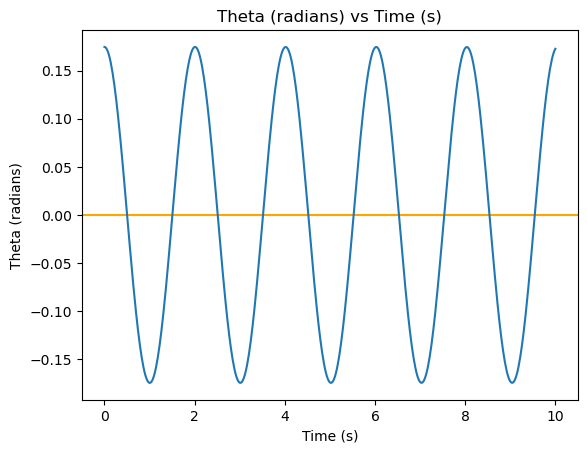

In [172]:
# Your code here
plt.axhline(y=0, label='Horizontal Line', color="orange")
plt.plot(time_values, theta_values, label="Numerical Solution")
plt.title("Theta (radians) vs Time (s)")
plt.xlabel("Time (s)")
plt.ylabel("Theta (radians)")

Print out the numerical period (what you calculated with scipy) to **four** significant digits.

In [173]:
# Your code here
print(f'{T_numerical:.4}')

2.004


Compare the results between the small-angle approximation and numerical calculation. How well does the approximation match the numerical result?

In [174]:
# Your comment here
# The approximation is very close. It is only off by around 0.004 which means it is petty accurate. The approximation matches the numerical 
# results

## 2 Using Curve_Fit with Covid-19 Data
Import `pandas` in the cell below.

In [175]:
# Your code here
import pandas as pd

Run the cell below. If that doesn't work, then just **paste** the link into a web browser and it should automatically download. Then you can put the `.csv` file in the same directory as this notebook.

In [176]:
url = "https://covid.ourworldindata.org/data/owid-covid-data.csv"

With the `pandas` function `read_csv`, import the data in the cell below as a dataframe `df`.

In [177]:
# Your code here
df = pd.read_csv("owid-covid-data.csv")

Select **United States** as the country and make a new data frame called `df_country` with only this information.

In [178]:
# Your code here
df_country = df[df["location"] == "United States"]

From your `df_country` dataframe, extract only the relevant columns: **"date"** and **"total_cases"**. 

*Hint: Use `.dropna()` to get rid of the other data.*

In [179]:
df_country = df_country[["date", "total_cases"]].dropna()

In your `df_country` dataframe, add a new column called **"days since start"** and covert the data to numerical days.

*Hint: You can just take the length of your dataframe (`range(len(df_country))`).*

In [180]:
# Your code here
df_country["days_since_start"] = range(len(df_country))

Print the first few rows of your `df_country` dataframe.

In [181]:
# Your code here
print(df_country.head())

              date  total_cases  days_since_start
403451  2020-01-05          0.0                 0
403452  2020-01-06          0.0                 1
403453  2020-01-07          0.0                 2
403454  2020-01-08          0.0                 3
403455  2020-01-09          0.0                 4


In the cell below, import `curve_fit`. Make sure to have `numpy` imported in this notebook as well.

In [182]:
# Your code here
from scipy.optimize import curve_fit

### Some background:
At the beginning of an outbreak, the number of cases follows an exponential growth model:

$$
C(t) = C_0 e^{rt}
$$

where
* $C(t)$ = number of cases at time $t$.
* $C_0$ = initial number of cases.
* $r$ = growth rate.
* $t$ = time in days.

Write a **function** called `exponential_growth` that takes in arguments `t`, `C_0` and `r`. Return the function given above.

In [183]:
# Your code here
def exponential_growth(t, C_0, r):
    return (C_0)*np.exp(r*t)

Make a new variable called `days` and another new variable called `cases`. To the `days` variable give it the first 30 rows (your column **"days_since_start"**) and to the `cases` variable give it the first 30 rows (your column **"total_cases"**).

In [184]:
# Your code here
days = df_country["days_since_start"].head(30)
cases = df_country["total_cases"].head(30)

With `curve_fit` fit the model. Give it the argument `p0 = [1, 0.1]`.

In [185]:
# Your code here
popt, pcov = curve_fit(exponential_growth,days,cases, p0 = [1, 0.1])

Extract the best-fit parameters from `popt`. Call them `C0_fit` and `r_fit`.

In [186]:
# Your code here
C0_fit, r_fit = popt

Print your variables `C0_fit` with **two** significant digits. Print your variables `r_fit` with **four** significant digits.

In [187]:
# Your code here
print(f'{C0_fit:.2}')
print(f'{r_fit:.4}')


0.12
0.1538


Make sure to have `matplotlib` imported. Make a variable called `future_days` give it a numpy range from `0` to `60`. We want to predict up to 60 days.

In [188]:
# Your code here
future_days = np.arange(61)

Make a variable called `predicted_cases` set it equal to your function `exponential_growth` with inputs being `future_days` and your `curve_fit` outputs. 

*Hint: You will want to use `*popt` as your `curve_fit` input.*

In [189]:
# Your code here 
predicted_cases = exponential_growth(future_days, *popt)

**Scater** the variable `cases` as a function of `days`. **Plot** the variable `future_days` as a function of `predicted_cases`. 

Don't forget a label for your x-axis, y-axis, title and legend.

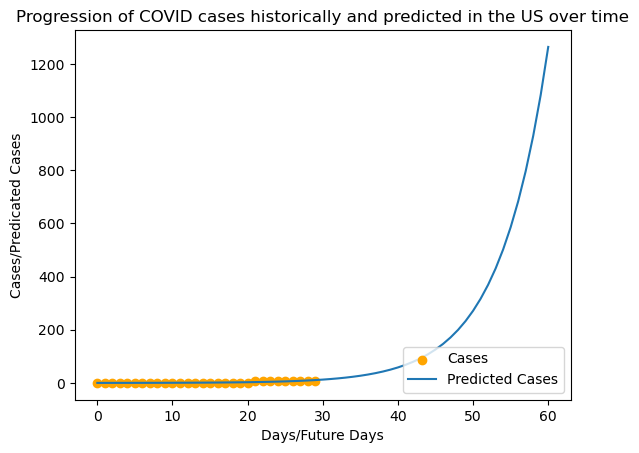

In [190]:
# Your code here
plt.scatter(days, cases, label="Cases", color="orange")
# Gonna assume you meant predicted_case as a function of future_days
plt.plot(future_days, predicted_cases, label="Predicted Cases")
plt.legend(["Cases", "Predicted Cases"], loc="lower right")
plt.xlabel("Days/Future Days")
plt.ylabel("Cases/Predicated Cases")
plt.title("Progression of COVID cases historically and predicted in the US over time")
plt.show()

How well does your exponential model fit the actual COVID-19 data? 

In [191]:
# Your comment here
# It fits pretty well, the prediction seems to overestimate a bit at the beginning

Make another plot but this time to **90 days**.

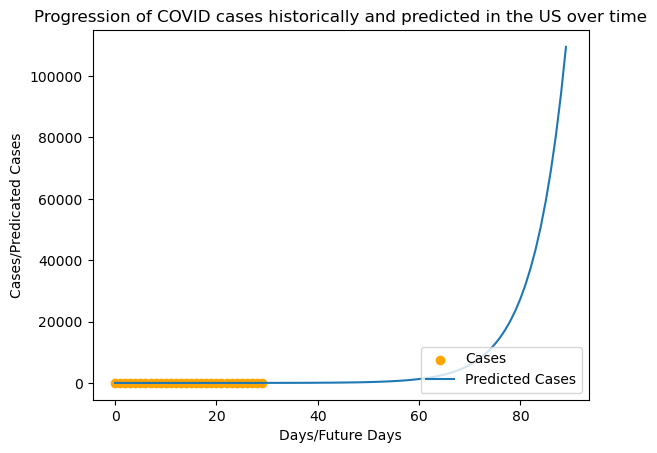

In [192]:
# Your code here
future_days = np.arange(90)
predicted_cases = exponential_growth(future_days, *popt)
plt.scatter(days, cases, label="Cases", color="orange")
# Gonna assume you meant predicted_case as a function of future_days
plt.plot(future_days, predicted_cases, label="Predicted Cases")
plt.legend(["Cases", "Predicted Cases"], loc="lower right")
plt.xlabel("Days/Future Days")
plt.ylabel("Cases/Predicated Cases")
plt.title("Progression of COVID cases historically and predicted in the US over time")
plt.show()

What does your model predict the number of cases to be at 87 days? Print in the cell below.

In [193]:
# Your code here
print(exponential_growth(88, *popt))

93884.35026617888


## 3 Seaborn
Use Seaborn to visualize your data, NOT matplotlib. 
1) Go to this website and **pick a dataset that interest you**: https://github.com/mwaskom/seaborn-data
2) Go to this website for documentation: https://seaborn.pydata.org/index.html
3) Import seaborn data (*Hint: You can use the function `sns.load dataset()`. For example, `sns.load dataset('planets')`.*
4) Make a cool plot!
5) With `scipy` add a model to your data. (This can be a different plot.)

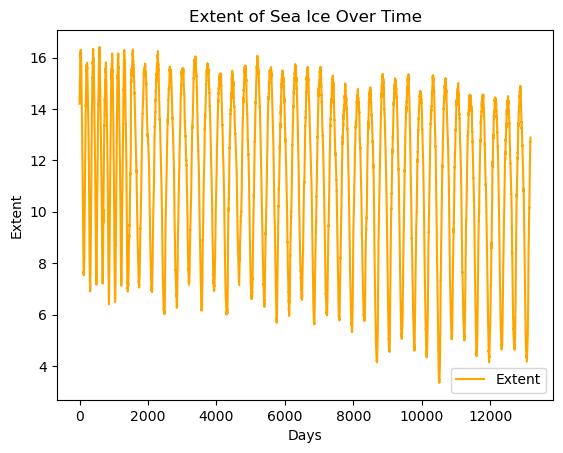

In [194]:
# Your code here
import seaborn as sns
data = sns.load_dataset('seaice')
days_ice = range(len(data))
extent = data["Extent"]
plt.plot(days_ice, extent, label="Extent", color="orange")
# Gonna assume you meant predicted_case as a function of future_days
plt.legend(["Extent"], loc="lower right")
plt.xlabel("Days")
plt.ylabel("Extent")
plt.title("Extent of Sea Ice Over Time")
plt.show()

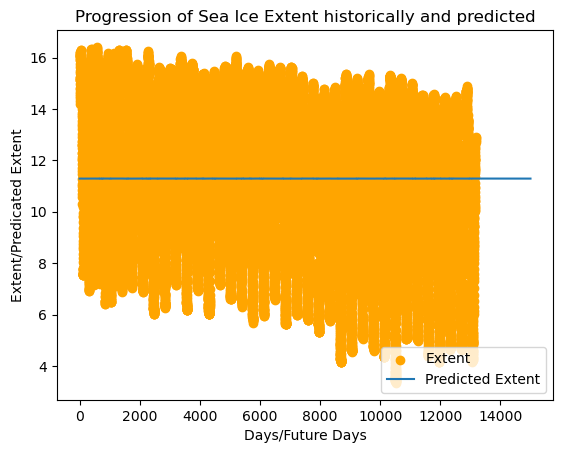

In [196]:
# Your code here
def sinusoidal(x,a,b,c,d):
    return a*np.sin(b*x+c) + d
future_days = np.arange(15000)
popt, pcov = curve_fit(sinusoidal,days_ice,extent)
predicted_extent = sinusoidal(future_days, *popt)
plt.scatter(days_ice, extent, label="Extent", color="orange")
plt.plot(future_days, predicted_extent, label="Predicted Extent")
plt.legend(["Extent", "Predicted Extent"], loc="lower right")
plt.xlabel("Days/Future Days")
plt.ylabel("Extent/Predicated Extent")
plt.title("Progression of Sea Ice Extent historically and predicted")
plt.show()

On it's own branch, submit this notebook to Gradescope! 